In [1]:
# !pip install gensim

In [2]:
import pandas as pd
import numpy as np

In [3]:
import nltk
custom_dir = '.devenv/state/venv/nltk_data' 
nltk.download('punkt_tab', download_dir=custom_dir)
nltk.download('stopwords', download_dir=custom_dir)
nltk.download('wordnet', download_dir=custom_dir)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     .devenv/state/venv/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     .devenv/state/venv/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     .devenv/state/venv/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [4]:
def preprocess_text(text):
    import re, string
    from nltk.tokenize import word_tokenize
    from nltk.corpus import stopwords
    from nltk.stem import WordNetLemmatizer

    word_tokens = word_tokenize(text)
    word_tokens = [word.lower() for word in word_tokens]
    word_tokens = [re.sub(r'[^\w\s]', '', token) for token in word_tokens if re.sub(r'[^\w\s]', '', token)]
    corpus_stop_words = set(stopwords.words('english'))
    word_tokens = [word for word in word_tokens if not word in corpus_stop_words]
    lemmatizer = WordNetLemmatizer()
    word_tokens = [lemmatizer.lemmatize(word) for word in word_tokens]
    return word_tokens

In [5]:
text = 'Hello everyone. How are you? Today is a sunny day and better than yesterday.'
word_tokens = preprocess_text(text)
print(word_tokens)

['hello', 'everyone', 'today', 'sunny', 'day', 'better', 'yesterday']


### Bag of Words

In [6]:
docs = []
docs.append('Hello everyone. How are you? Today is a sunny day and better than yesterday.')
docs.append("How's everyone doing, today?  It is not sunny today.")
docs

['Hello everyone. How are you? Today is a sunny day and better than yesterday.',
 "How's everyone doing, today?  It is not sunny today."]

##### Preprocess and Counter

In [7]:
# Preprocess each documents
processed_docs = [preprocess_text(doc) for doc in docs]
print(processed_docs)

# Flatten list
all_tokens = [word for doc in processed_docs for word in doc]
print(all_tokens)

# Unique sorted vocabulary
vocabs = sorted(set(all_tokens))
print(vocabs)

[['hello', 'everyone', 'today', 'sunny', 'day', 'better', 'yesterday'], ['everyone', 'today', 'sunny', 'today']]
['hello', 'everyone', 'today', 'sunny', 'day', 'better', 'yesterday', 'everyone', 'today', 'sunny', 'today']
['better', 'day', 'everyone', 'hello', 'sunny', 'today', 'yesterday']


In [8]:
def create_bow_vector(tokens, vocabs):
    from collections import Counter
    word_count = Counter(tokens)
    return [word_count[word] for word in vocabs]

# Count frequencies of unique words in each document
bow_freqs = [create_bow_vector(doc, vocabs) for doc in processed_docs]
bow_vectors = pd.DataFrame(bow_freqs, columns=vocabs)
print(bow_vectors)

   better  day  everyone  hello  sunny  today  yesterday
0       1    1         1      1      1      1          1
1       0    0         1      0      1      2          0


##### CountVectorizer

In [9]:
# Create Bag of Words using CountVectorizer
# CountVectorizer tokenizes, lowercases (by default), and creates document-term matrix
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
result = vectorizer.fit_transform(docs)

# Show Vocabulary
print("Vocabulary:\n", vectorizer.vocabulary_)  # value in dictionary is word index in matrix result
# Show vocab frequency in each document
print(result.toarray())

Vocabulary:
 {'hello': 6, 'everyone': 5, 'how': 7, 'are': 1, 'you': 15, 'today': 13, 'is': 8, 'sunny': 11, 'day': 3, 'and': 0, 'better': 2, 'than': 12, 'yesterday': 14, 'doing': 4, 'it': 9, 'not': 10}
[[1 1 1 1 0 1 1 1 1 0 0 1 1 1 1 1]
 [0 0 0 0 1 1 0 1 1 1 1 1 0 2 0 0]]


In [10]:
# Rearrange outputs to see word frequencies in each document
vocabs = {value: key for key, value in vectorizer.vocabulary_.items()}
feature_names = []
for i in range(len(vocabs)):
    feature_names.append(vocabs[i])

bow_vectors2 = pd.DataFrame(result.toarray(), columns=feature_names)
print(bow_vectors2)

   and  are  better  day  doing  everyone  hello  how  is  it  not  sunny  \
0    1    1       1    1      0         1      1    1   1   0    0      1   
1    0    0       0    0      1         1      0    1   1   1    1      1   

   than  today  yesterday  you  
0     1      1          1    1  
1     0      2          0    0  


### N-Grams

In [11]:
docs = []
docs.append('Machine learning models learn from data.')
docs.append('Deep learning models require large data.')
docs.append('Machine learning improves decision making.')
docs.append('Data science uses machine learning techniques.')
docs.append('Large data improves machine performance.')
docs

['Machine learning models learn from data.',
 'Deep learning models require large data.',
 'Machine learning improves decision making.',
 'Data science uses machine learning techniques.',
 'Large data improves machine performance.']

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(ngram_range=(1,2))  # unigram + bigram
result = vectorizer.fit_transform(docs)

# Show Vocabulary
print("Vocabulary:\n", vectorizer.vocabulary_)  # value in dictionary is word index in matrix result
# Show vocab frequency in each document
print(result.toarray())

Vocabulary:
 {'machine': 20, 'learning': 16, 'models': 24, 'learn': 14, 'from': 7, 'data': 0, 'machine learning': 21, 'learning models': 18, 'models learn': 25, 'learn from': 15, 'from data': 8, 'deep': 5, 'require': 28, 'large': 12, 'deep learning': 6, 'models require': 26, 'require large': 29, 'large data': 13, 'improves': 9, 'decision': 3, 'making': 23, 'learning improves': 17, 'improves decision': 10, 'decision making': 4, 'science': 30, 'uses': 33, 'techniques': 32, 'data science': 2, 'science uses': 31, 'uses machine': 34, 'learning techniques': 19, 'performance': 27, 'data improves': 1, 'improves machine': 11, 'machine performance': 22}
[[1 0 0 0 0 0 0 1 1 0 0 0 0 0 1 1 1 0 1 0 1 1 0 0 1 1 0 0 0 0 0 0 0 0 0]
 [1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 0 1 0 0 0 0 0 1 0 1 0 1 1 0 0 0 0 0]
 [0 0 0 1 1 0 0 0 0 1 1 0 0 0 0 0 1 1 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 0]
 [1 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 1 1 0 0 0 0 0 0 0 0 1 1 1 1 1]
 [1 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 1 0 1 0 0 0 0 

In [13]:
# Rearrange outputs to see word frequencies in each document
vocabs = {value: key for key, value in vectorizer.vocabulary_.items()}
feature_names = []
for i in range(len(vocabs)):
    feature_names.append(vocabs[i])

ngrams_vector = pd.DataFrame(result.toarray(), columns=feature_names)
print(ngrams_vector)

   data  data improves  data science  decision  decision making  deep  \
0     1              0             0         0                0     0   
1     1              0             0         0                0     1   
2     0              0             0         1                1     0   
3     1              0             1         0                0     0   
4     1              1             0         0                0     0   

   deep learning  from  from data  improves  ...  models learn  \
0              0     1          1         0  ...             1   
1              1     0          0         0  ...             0   
2              0     0          0         1  ...             0   
3              0     0          0         0  ...             0   
4              0     0          0         1  ...             0   

   models require  performance  require  require large  science  science uses  \
0               0            0        0              0        0             0   
1 

### TF-IDF

In [14]:
docs = []
docs.append('It is going to rain today.')
docs.append('Today I am not going outside.')
docs.append('I am going to watch TV.')
docs

['It is going to rain today.',
 'Today I am not going outside.',
 'I am going to watch TV.']

In [15]:
from sklearn.feature_extraction.text import TfidfVectorizer
tfidf = TfidfVectorizer(stop_words='english')
result = tfidf.fit_transform(docs)
print(tfidf.get_feature_names_out())
print(result.toarray())

['going' 'outside' 'rain' 'today' 'tv' 'watch']
[[0.42544054 0.         0.72033345 0.54783215 0.         0.        ]
 [0.42544054 0.72033345 0.         0.54783215 0.         0.        ]
 [0.38537163 0.         0.         0.         0.65249088 0.65249088]]


In [16]:
feature_names = tfidf.get_feature_names_out()
tfidf_vectors = pd.DataFrame(result.toarray(), columns=feature_names)
print(tfidf_vectors)

      going   outside      rain     today        tv     watch
0  0.425441  0.000000  0.720333  0.547832  0.000000  0.000000
1  0.425441  0.720333  0.000000  0.547832  0.000000  0.000000
2  0.385372  0.000000  0.000000  0.000000  0.652491  0.652491


### Word2Vec

In [17]:
docs = []
docs.append('A man lives with two cats and a dog in his apartment.')
docs.append('Inside his apartment, there are a bed, a table and four chairs.')
docs.append('The man is sleeping on the bed.')
docs.append('One cat stands on the table.')
docs.append('The other cat sits on one chair.')
docs.append('The dog sleeps on the floor.')
docs

['A man lives with two cats and a dog in his apartment.',
 'Inside his apartment, there are a bed, a table and four chairs.',
 'The man is sleeping on the bed.',
 'One cat stands on the table.',
 'The other cat sits on one chair.',
 'The dog sleeps on the floor.']

In [18]:
# Preprocess documents
processed_docs = [preprocess_text(doc) for doc in docs]
print(processed_docs)

[['man', 'life', 'two', 'cat', 'dog', 'apartment'], ['inside', 'apartment', 'bed', 'table', 'four', 'chair'], ['man', 'sleeping', 'bed'], ['one', 'cat', 'stand', 'table'], ['cat', 'sits', 'one', 'chair'], ['dog', 'sleep', 'floor']]


In [19]:
# Flatten list
all_tokens = [word for doc in processed_docs for word in doc]
print(all_tokens)

# Unique sorted vocabulary
vocabs = sorted(set(all_tokens))
print(vocabs)
print(len(vocabs))

['man', 'life', 'two', 'cat', 'dog', 'apartment', 'inside', 'apartment', 'bed', 'table', 'four', 'chair', 'man', 'sleeping', 'bed', 'one', 'cat', 'stand', 'table', 'cat', 'sits', 'one', 'chair', 'dog', 'sleep', 'floor']
['apartment', 'bed', 'cat', 'chair', 'dog', 'floor', 'four', 'inside', 'life', 'man', 'one', 'sits', 'sleep', 'sleeping', 'stand', 'table', 'two']
17


#### Word2Vec CBOW Model

In [20]:
# Note that Word2Vec takes nested list of words as first paarameter
# vector_size (int, optional) – Dimensionality of the word vectors.
# window (int, optional) – Maximum distance between the current and predicted word within a sentence.
# min_count (int, optional) – Ignores all words with total frequency lower than this.
# sg ({0, 1}, optional) – 1 = skip gram, 0 = CBOW

from gensim.models import Word2Vec
model = Word2Vec(sentences=processed_docs,
                 vector_size=100,   # size of word embeddings
                 window=5,          # context window size
                 min_count=1,       # include all words
                 workers=4,         # number of CPU threads used to train the model in parallel.
                 sg=0               # CBOW
                )

In [21]:
# Get all possible words from Word2Vec model
vocab_list = list(model.wv.key_to_index.keys())
print(len(vocab_list))
vocab_list

17


['cat',
 'one',
 'chair',
 'table',
 'bed',
 'apartment',
 'dog',
 'man',
 'floor',
 'sleep',
 'sits',
 'stand',
 'sleeping',
 'four',
 'inside',
 'two',
 'life']

In [22]:
vector = model.wv['cat']
print("Vector length:", len(vector))   # output will be a 100-dimensional vector.
print(vector)

Vector length: 100
[-5.3622725e-04  2.3643136e-04  5.1033497e-03  9.0092728e-03
 -9.3029495e-03 -7.1168090e-03  6.4588725e-03  8.9729885e-03
 -5.0154282e-03 -3.7633716e-03  7.3805046e-03 -1.5334714e-03
 -4.5366134e-03  6.5540518e-03 -4.8601604e-03 -1.8160177e-03
  2.8765798e-03  9.9187379e-04 -8.2852151e-03 -9.4488179e-03
  7.3117660e-03  5.0702621e-03  6.7576934e-03  7.6286553e-04
  6.3508903e-03 -3.4053659e-03 -9.4640139e-04  5.7685734e-03
 -7.5216377e-03 -3.9361035e-03 -7.5115822e-03 -9.3004224e-04
  9.5381187e-03 -7.3191668e-03 -2.3337686e-03 -1.9377411e-03
  8.0774371e-03 -5.9308959e-03  4.5162440e-05 -4.7537340e-03
 -9.6035507e-03  5.0072931e-03 -8.7595852e-03 -4.3918253e-03
 -3.5099984e-05 -2.9618145e-04 -7.6612402e-03  9.6147433e-03
  4.9820580e-03  9.2331432e-03 -8.1579173e-03  4.4957981e-03
 -4.1370760e-03  8.2453608e-04  8.4986202e-03 -4.4621765e-03
  4.5175003e-03 -6.7869602e-03 -3.5484887e-03  9.3985079e-03
 -1.5776526e-03  3.2137157e-04 -4.1406299e-03 -7.6826881e-03
 -1.5

In [23]:
# Find most similar words to the query word
query_word = 'cat'
similar_words = model.wv.most_similar(query_word)
print(similar_words)

[('life', 0.21884241700172424), ('sleep', 0.21617406606674194), ('sleeping', 0.0930900052189827), ('man', 0.09291722625494003), ('stand', 0.07963486760854721), ('sits', 0.06285078823566437), ('two', 0.054300934076309204), ('floor', 0.0270574688911438), ('dog', 0.016149908304214478), ('one', -0.01083916611969471)]


In [24]:
# Find Similarity between 2 words
word1 = 'cat'
word2 = 'dog'
similarity_score = model.wv.similarity(word1, word2)
print(similarity_score)

0.016149908


In [25]:
# Find Similarity between 2 words
word1 = 'cat'
word2 = 'man'
similarity_score = model.wv.similarity(word1, word2)
print(similarity_score)

0.09291722


In [26]:
def compute_cosine_similarity(vector1, vector2):
    squared_first_sum = sum([val*val for val in vector1])**0.5
    squared_second_sum = sum([val*val for val in vector2])**0.5
    cosine_similar = np.dot(vector1, vector2) / (squared_first_sum*squared_second_sum)
    return cosine_similar

# Find Similarity between 2 word vectors using cosine similarity
vector1 = model.wv['cat']
vector2 = model.wv['dog']
cosine_similar = compute_cosine_similarity(vector1, vector2)
print(cosine_similar)

0.016149925


In [27]:
# Find Similarity between 2 word vectors using cosine similarity
vector1 = model.wv['cat']
vector2 = model.wv['man']
cosine_similar = compute_cosine_similarity(vector1, vector2)
print(cosine_similar)

0.09291724


In [28]:
# See a list of top 10 most positively similar word to cat (default size of list = 10)
model.wv.most_similar(positive=['cat'])

[('life', 0.21884241700172424),
 ('sleep', 0.21617406606674194),
 ('sleeping', 0.0930900052189827),
 ('man', 0.09291722625494003),
 ('stand', 0.07963486760854721),
 ('sits', 0.06285078823566437),
 ('two', 0.054300934076309204),
 ('floor', 0.0270574688911438),
 ('dog', 0.016149908304214478),
 ('one', -0.01083916611969471)]

In [29]:
# See a list of top 5 most positively similar word to dog
model.wv.most_similar(positive=['dog'], topn=5)

[('life', 0.16377438604831696),
 ('chair', 0.14595463871955872),
 ('sits', 0.05047360435128212),
 ('table', 0.04155296832323074),
 ('bed', 0.03470911085605621)]

In [30]:
# See a list of top 10 most negatively similar word to cat (default size of list = 10)
model.wv.most_similar(negative=['cat'])

[('table', 0.111670583486557),
 ('apartment', 0.05986497551202774),
 ('chair', 0.05234673246741295),
 ('four', 0.04124332219362259),
 ('inside', 0.03771958127617836),
 ('bed', 0.02774733304977417),
 ('one', 0.01083916611969471),
 ('dog', -0.016149908304214478),
 ('floor', -0.0270574688911438),
 ('two', -0.054300934076309204)]

In [31]:
# See a list of top 5 most negatively similar word to dog
model.wv.most_similar(negative=['dog'], topn=5)

[('two', 0.14642870426177979),
 ('one', 0.1140967458486557),
 ('stand', 0.0838371217250824),
 ('sleeping', -0.0008159911958500743),
 ('sleep', -0.001914476277306676)]

In [32]:
# Select word that least match the remaining words in the list
print(model.wv.doesnt_match(['dog', 'man', 'cat']))
similarity_score1 = model.wv.similarity('dog', 'man')
similarity_score2 = model.wv.similarity('man', 'cat')
similarity_score3 = model.wv.similarity('dog', 'cat')
print(similarity_score1, similarity_score2, similarity_score3)

dog
0.004852578 0.09291722 0.016149908


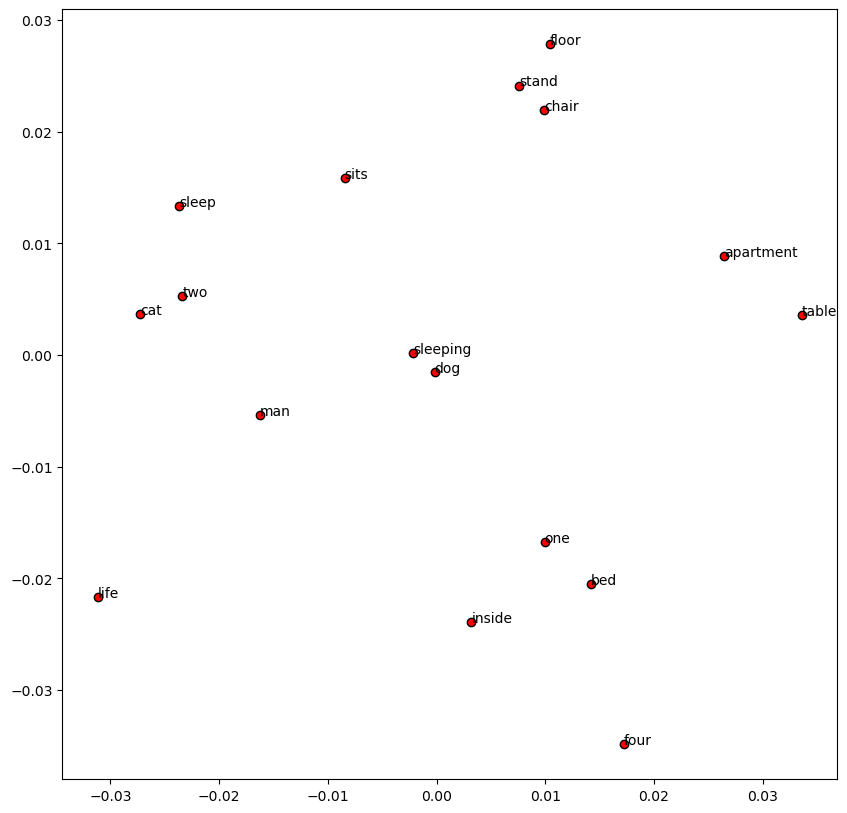

In [33]:
# Plot similarities between each word

# Source: https://medium.com/@manansuri/a-dummys-guide-to-word2vec-456444f3c673
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
%matplotlib inline
def display_pca_scatterplot(model, words=None, sample=0):
    if words == None:
        if sample > 0:
            words = np.random.choice(list(model.vocab.keys()), sample)
        else:
            words = [ word for word in model.vocab ]

    word_vectors = np.array([model[w] for w in words])

    twodim = PCA().fit_transform(word_vectors)[:,:2]

    plt.figure(figsize=(10,10))
    plt.scatter(twodim[:,0], twodim[:,1], edgecolors='k', c='r')
    for word, (x,y) in zip(words, twodim):
        #plt.text(x+0.05, y+0.05, word)
        plt.text(x, y, word)
    plt.show()

display_pca_scatterplot(model.wv, vocab_list)

In [34]:
# Predict the target word, from the context word
# Based on P(target word∣context words)
# Work with CBOW model only

# Probability is computed by
# 1. Takes and averages context word vectors
# 2. Multiplies by output weight matrix W
# 3. Applies softmax
# 4. Returns highest probability words
model.predict_output_word(['cat'])

[('table', np.float32(0.05882374)),
 ('dog', np.float32(0.05882369)),
 ('life', np.float32(0.05882369)),
 ('inside', np.float32(0.058823667)),
 ('one', np.float32(0.05882366)),
 ('bed', np.float32(0.05882364)),
 ('four', np.float32(0.058823593)),
 ('stand', np.float32(0.058823567)),
 ('man', np.float32(0.058823533)),
 ('two', np.float32(0.058823522))]

In [35]:
# Predict the target word, from the list of context words
model.predict_output_word(['cat', 'dog'])

[('life', np.float32(0.058824196)),
 ('sleep', np.float32(0.058823925)),
 ('two', np.float32(0.05882391)),
 ('inside', np.float32(0.058823828)),
 ('stand', np.float32(0.058823776)),
 ('man', np.float32(0.058823757)),
 ('bed', np.float32(0.058823746)),
 ('sits', np.float32(0.058823705)),
 ('table', np.float32(0.0588236)),
 ('one', np.float32(0.058823597))]

##### Model can be saved and loaded to train later

In [36]:
# Model can be saved and reload to use later
model.save('cbow_model')

In [37]:
# Load model and continue training
new_model = Word2Vec.load('cbow_model')
new_texts = ['The man brings three chickens into the apartment']
new_processed_docs = [preprocess_text(doc) for doc in new_texts]
# Flatten list
new_processed_tokens = [word for doc in new_processed_docs for word in doc]
print(new_processed_tokens)

['man', 'brings', 'three', 'chicken', 'apartment']


In [38]:
# Build new vocab
# Compare last and new vocab lists
new_model.build_vocab([new_processed_tokens], update=True)
new_vocab_list = list(new_model.wv.key_to_index.keys())
print(len(vocab_list))
print(len(new_vocab_list))
new_vocab_list

17
20


['cat',
 'one',
 'chair',
 'table',
 'bed',
 'apartment',
 'dog',
 'man',
 'floor',
 'sleep',
 'sits',
 'stand',
 'sleeping',
 'four',
 'inside',
 'two',
 'life',
 'brings',
 'three',
 'chicken']

In [39]:
new_model.train(new_processed_tokens, total_examples=new_model.corpus_count, epochs=model.epochs)

(0, 150)

In [40]:
# Find Similarity between 2 words
new_model.wv.similarity('cat', 'chicken')

np.float32(0.0024360553)

In [41]:
new_model.predict_output_word(['chicken'])

[('bed', np.float32(0.05000066)),
 ('sits', np.float32(0.05000045)),
 ('chair', np.float32(0.050000384)),
 ('life', np.float32(0.050000314)),
 ('cat', np.float32(0.050000224)),
 ('table', np.float32(0.050000224)),
 ('floor', np.float32(0.050000172)),
 ('two', np.float32(0.050000016)),
 ('sleep', np.float32(0.049999963)),
 ('stand', np.float32(0.049999904))]

#### Word2Vec Skip-Gram Model

In [42]:
sg_model = Word2Vec(sentences=processed_docs,
                    vector_size=100,
                    window=5,
                    min_count=1,
                    sg=1   # Skip-gram
                   )

In [43]:
# Get all possible words from Word2Vec model
vocab_list = list(sg_model.wv.key_to_index.keys())
vocab_list

['cat',
 'one',
 'chair',
 'table',
 'bed',
 'apartment',
 'dog',
 'man',
 'floor',
 'sleep',
 'sits',
 'stand',
 'sleeping',
 'four',
 'inside',
 'two',
 'life']

In [44]:
# Find most similar words to the query word
query_word = 'cat'
similar_words = sg_model.wv.most_similar(query_word)
print(similar_words)

[('life', 0.21883904933929443), ('sleep', 0.21617937088012695), ('sleeping', 0.09308990836143494), ('man', 0.09291722625494003), ('stand', 0.07963486760854721), ('sits', 0.06285078823566437), ('two', 0.05436888709664345), ('floor', 0.0270574688911438), ('dog', 0.016252489760518074), ('one', -0.01083916611969471)]


In [45]:
# Find Similarity between 2 words
word1 = 'cat'
word2 = 'dog'
similarity_score = sg_model.wv.similarity(word1, word2)
print(similarity_score)

0.016252495


In [46]:
# Find Similarity between 2 words
word1 = 'cat'
word2 = 'table'
similarity_score = model.wv.similarity(word1, word2)
print(similarity_score)

-0.11167058
